# Higher-order rules across the disease stages

## Configuration & Constants
Everything to tune lives here.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os
import sys
import ast
import itertools
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Add root to path for utils
sys.path.append(os.path.abspath('../..'))   # project root
sys.path.append(os.path.abspath('..'))          # shared helpers, one level up

# Shared loader + rule-name cleaning (also used by the other result-summary notebooks)
import data_helper as dh
from data_helper import base_items, clean_items, check_rule_overlap

# Plotting helpers live next to this notebook
import complex_stages_vis as sv

In [3]:
# ==========================================
# CONFIGURATION & CONSTANTS
# ==========================================
# Which run: data_helper.RESULT_CSV_PATH, shared by every notebook. Run
# prepare_data.ipynb once on a new run to split its rules into the two files.

# Which rules take part
RULE_MAX_ITEMS = 4     # up to four items, so the longer rules come in too
KIND    = 'attracts'   # 'attracts', 'avoids', or None for both
NO_SELF = True         # drop rules where a cell type repeats
MAX_FDR = 0.05         # a rule counts as present in a FOV only this significant

# How FOVs are grouped
SCORE_COLUMN = 'Pathological score'
STAGE_ORDER  = ['Control', 'Mild', 'Severe']
ORGAN_ORDER  = ['Colon', 'Duodenum']

SHAPE_ORDER  = ['ant-complex', 'con-complex', 'both-complex']

# A rule has to be worth reading in this many FOVs before it gets a row.
MIN_FOVS = 5
TOP_N    = 18          # rows per figure, the biggest movers first
MIN_N    = 5           # below this many FOVs behind a point, it is drawn faintly

# How much detail the figures break into. Both halves merge by default.
# True splits 'the rule is here and adds something' into
#   'beat a real shorter rule'  and  'nothing shorter was mined'.
SPLIT_ADDS = False
# True splits 'the pairs cover it, the rule adds nothing' into
#   'here, but a shorter rule already said it'  and  'not here at all, but its pairs are'.
SPLIT_COVERED = False

## Load Data

In [4]:
# Load cells, FOVs and biopsies (shared loader, see data_helper.py).
df_cells, df_fovs, df_biopsy = dh.load_spatial_data()

Dropped 21 FOVs: Control_S
Loaded 598093 cells; FOVs: 267, biopsies: 73, patients: 71


In [5]:
df_results = dh.load_results(rule_max_items=RULE_MAX_ITEMS, kind=KIND, max_fdr=1.0,
                             informative_only=False)

Read results_CN_pairwise.csv + results_CN_complex.csv
Loaded 1190114 rules.
Kept 1190114 rules at FDR <= 1.0.
Kept 727458 rules (max_items=4, kind=attracts).


## What state is a rule in, in one FOV?

Five states, and every FOV of a stage lands in exactly one of them:

| state | the rule | its pairwise parts |
| --- | --- | --- |
| `adds` | there, and beat a real shorter rule | there |
| `new` | there, nothing shorter was mined | not there |
| `redundant` | there, but a shorter rule already said it | there |
| `pairs_only` | not there | there |
| `nothing` | not there | not there |

There is one more number the figures can show, not a state but a share of one:
**earns** = `informative / (informative + covered)`. Of the FOVs where the rule *or at
least one of its pairwise parts* turned up, how often the rule was the better
description. Note the denominator is loose - a three-item rule counts as covered when a
single one of its pairs fired, not all of them.

`adds` and `new` merge into **informative** - the rule is here and adds something.
`redundant` and `pairs_only` merge into **covered** - the pairwise level already
accounts for this FOV, whether or not the longer rule turned up. `SPLIT_ADDS` and
`SPLIT_COVERED` decide whether a figure shows the pair or the merge.

`new` already says the parts were missing, so the only place worth measuring them
separately is where the rule itself is absent. That is `pairs_only`.

In [6]:
def cell_types(items):
    """The cell types a stored item list names, roles dropped and repeats collapsed."""
    strip = lambda item: item.replace('_CENTER', '').replace('_NEIGHBOR', '')
    return tuple(sorted({strip(i) for i in ast.literal_eval(items)}))


def drop_self_rules(rules, no_self=NO_SELF):
    """Drop rules where a cell type repeats (Paneth + Paneth -> Goblet)."""
    if not no_self:
        return rules
    repeats = [check_rule_overlap(base_items(a), base_items(c))
               for a, c in zip(rules['Antecedents'], rules['Consequents'])]
    return rules[~pd.Series(repeats, index=rules.index)]


def prepare(rules, df_fovs, max_fdr=MAX_FDR):
    """Add the columns the counting needs: cell types, a clean name, significance."""
    rules = rules[rules['FOV'].isin(df_fovs['FOV'])]
    ready = rules[rules['Individual_FDR'] <= max_fdr].copy()
    ready['ant_t'] = ready['Antecedents'].map(cell_types)
    ready['con_t'] = ready['Consequents'].map(cell_types)
    ready['name'] = (ready['Antecedents'].map(clean_items) + ' -> '
                     + ready['Consequents'].map(clean_items))
    print(f"{len(ready):,} rules at FDR <= {max_fdr}")
    return ready


ready = prepare(df_results, df_fovs)

264,956 rules at FDR <= 0.05


In [7]:
def pairs_by_fov(ready):
    """Per FOV, the (antecedent type -> consequent type) pairs a two-item rule made."""
    pairwise = ready[ready['Rule_Type'] == 'pairwise']
    found = defaultdict(set)
    for fov, ant, con in zip(pairwise['FOV'], pairwise['ant_t'], pairwise['con_t']):
        if len(ant) == 1 and len(con) == 1:
            found[fov].add((ant[0], con[0]))
    return found


def rule_state_by_fov(ready):
    """Per rule, per FOV, the state the rule itself is in - ignoring its parts.

    A rule can be mined more than once in one FOV (the same cell types in different
    roles). The best of those stands for it: beating a shorter rule outranks having
    nothing shorter to beat, which outranks being told it was already said.
    """
    rank = {'adds': 3, 'new': 2, 'redundant': 1}
    longer = ready[ready['Rule_Type'].isin(SHAPE_ORDER)]

    state = defaultdict(dict)
    for name, fov, adds, verdict in zip(longer['name'], longer['FOV'],
                                        longer['Adds_Information'],
                                        longer['Complex_Class']):
        now = 'redundant' if not adds else ('new' if verdict == 'new' else 'adds')
        if rank[now] > rank.get(state[name].get(fov, ''), 0):
            state[name][fov] = now
    return state

In [8]:
def stage_counts(ready, df_fovs, stages=STAGE_ORDER, min_fovs=MIN_FOVS, where=None,
                 no_self=NO_SELF):
    """One row per (rule, stage): how many of that stage's FOVs are in each state.

    where   : a {column: value} filter on the FOVs, e.g. {'Organ': 'Colon'}. The counting
              and the denominators both follow it, so a per-organ figure is honest.
    no_self : drop the rules where a cell type repeats.
    """
    ready = drop_self_rules(ready, no_self)
    fovs = df_fovs
    for column, value in (where or {}).items():
        fovs = fovs[fovs[column] == value]
    stage_fovs = {s: set(fovs.loc[fovs[SCORE_COLUMN] == s, 'FOV']) for s in stages}
    print({s: len(f) for s, f in stage_fovs.items()})

    pairs, state = pairs_by_fov(ready), rule_state_by_fov(ready)
    parts = (ready[ready['Rule_Type'].isin(SHAPE_ORDER)]
             .drop_duplicates('name').set_index('name')[['ant_t', 'con_t']])

    # Only rules worth reading somewhere inside this slice get a row.
    seen = {name: sum(1 for f, s in per_fov.items()
                      if s != 'redundant' and any(f in v for v in stage_fovs.values()))
            for name, per_fov in state.items()}
    keep = [name for name, count in seen.items() if count >= min_fovs]
    print(f"{len(keep)} rules worth reading in {min_fovs}+ FOVs")

    rows = []
    for name in keep:
        ant_t, con_t = parts.loc[name, 'ant_t'], parts.loc[name, 'con_t']
        wanted = set(itertools.product(ant_t, con_t))
        for stage in stages:
            here = stage_fovs[stage]
            counts = {'adds': 0, 'new': 0, 'redundant': 0, 'pairs_only': 0, 'nothing': 0}
            for fov in here:
                found = state[name].get(fov)
                if found:
                    counts[found] += 1
                elif wanted & pairs.get(fov, set()):
                    counts['pairs_only'] += 1
                else:
                    counts['nothing'] += 1
            rows.append({'name': name, 'stage': stage, 'n_fovs': len(here), **counts})

    counts = pd.DataFrame(rows)
    # The two coarse states, each the sum of its pair, so a figure can ask for either.
    counts['informative'] = counts['adds'] + counts['new']
    counts['covered'] = counts['redundant'] + counts['pairs_only']
    for column in ('adds', 'new', 'informative', 'redundant', 'pairs_only', 'covered',
                   'nothing'):
        counts[f'{column}_share'] = counts[column] / counts['n_fovs']

    # The conditional one: of the FOVs where the rule OR at least one of its pairwise
    # parts turned up, how often the rule was the better description. Abundance drops
    # out, so a rare rule that always earns its place is not buried by a common one.
    counts['n_present'] = counts['informative'] + counts['covered']
    counts['earns_share'] = counts['informative'] / counts['n_present'].replace(0, np.nan)
    return counts

In [9]:
def movers(counts, value='informative', stages=STAGE_ORDER, top_n=TOP_N, min_n=None):
    """The rules whose `value` moves most across the stages.

    min_n : require this many FOVs behind the rule in EVERY stage before it can be
            picked. A share like 'earns' swings to 0 or 100 on one or two FOVs, so
            without this the ranking finds the thinnest evidence, not the biggest change.
    """
    if min_n is not None:
        behind = counts.pivot(index='name', columns='stage', values='n_present')[stages]
        steady = behind.min(axis=1) >= min_n
        counts = counts[counts['name'].isin(behind.index[steady])]
        print(f"{steady.sum()} rules with {min_n}+ FOVs behind them in every stage")

    wide = counts.pivot(index='name', columns='stage', values=f'{value}_share')[stages]
    spread = (wide.max(axis=1) - wide.min(axis=1)).sort_values(ascending=False)
    picked = list(spread.head(top_n).index)

    # Ordered by which stage the rule peaks in, then by how far it moves, so the rows
    # gather into blocks instead of arriving alphabetically.
    picked.sort(key=lambda n: (list(stages).index(wide.loc[n].idxmax()), -spread[n]))

    rows = counts[counts['name'].isin(picked)].copy()
    rows['name'] = pd.Categorical(rows['name'], categories=picked, ordered=True)
    return rows.sort_values(['name', 'stage'])


counts = stage_counts(ready, df_fovs)
display(counts.head(6))

{'Control': 56, 'Mild': 143, 'Severe': 68}
1528 rules worth reading in 5+ FOVs


,name,stage,n_fovs,adds,new,redundant,pairs_only,nothing,informative,covered,adds_share,new_share,informative_share,redundant_share,pairs_only_share,covered_share,nothing_share,n_present,earns_share
0,"Fibroblast, Paneth -> CD4T, Epithelial",Control,56,2,0,1,16,37,2,17,0.035714,0.000000,0.035714,0.017857,0.285714,0.303571,0.660714,19,0.105263
1,"Fibroblast, Paneth -> CD4T, Epithelial",Mild,143,12,0,10,36,85,12,46,0.083916,0.000000,0.083916,0.069930,0.251748,0.321678,0.594406,58,0.206897
2,"Fibroblast, Paneth -> CD4T, Epithelial",Severe,68,1,0,0,2,65,1,2,0.014706,0.000000,0.014706,0.000000,0.029412,0.029412,0.955882,3,0.333333
3,"Fibroblast, Paneth -> Epithelial",Control,56,0,1,9,3,43,1,12,0.000000,0.017857,0.017857,0.160714,0.053571,0.214286,0.767857,13,0.076923
4,"Fibroblast, Paneth -> Epithelial",Mild,143,0,3,34,8,98,3,42,0.000000,0.020979,0.020979,0.237762,0.055944,0.293706,0.685315,45,0.066667
5,"Fibroblast, Paneth -> Epithelial",Severe,68,0,4,2,0,62,4,2,0.000000,0.058824,0.058824,0.029412,0.000000,0.029412,0.911765,6,0.666667


## The three views

Same table each time. `value=` picks which state a one-number figure colours by, and
`where=` narrows the FOVs.

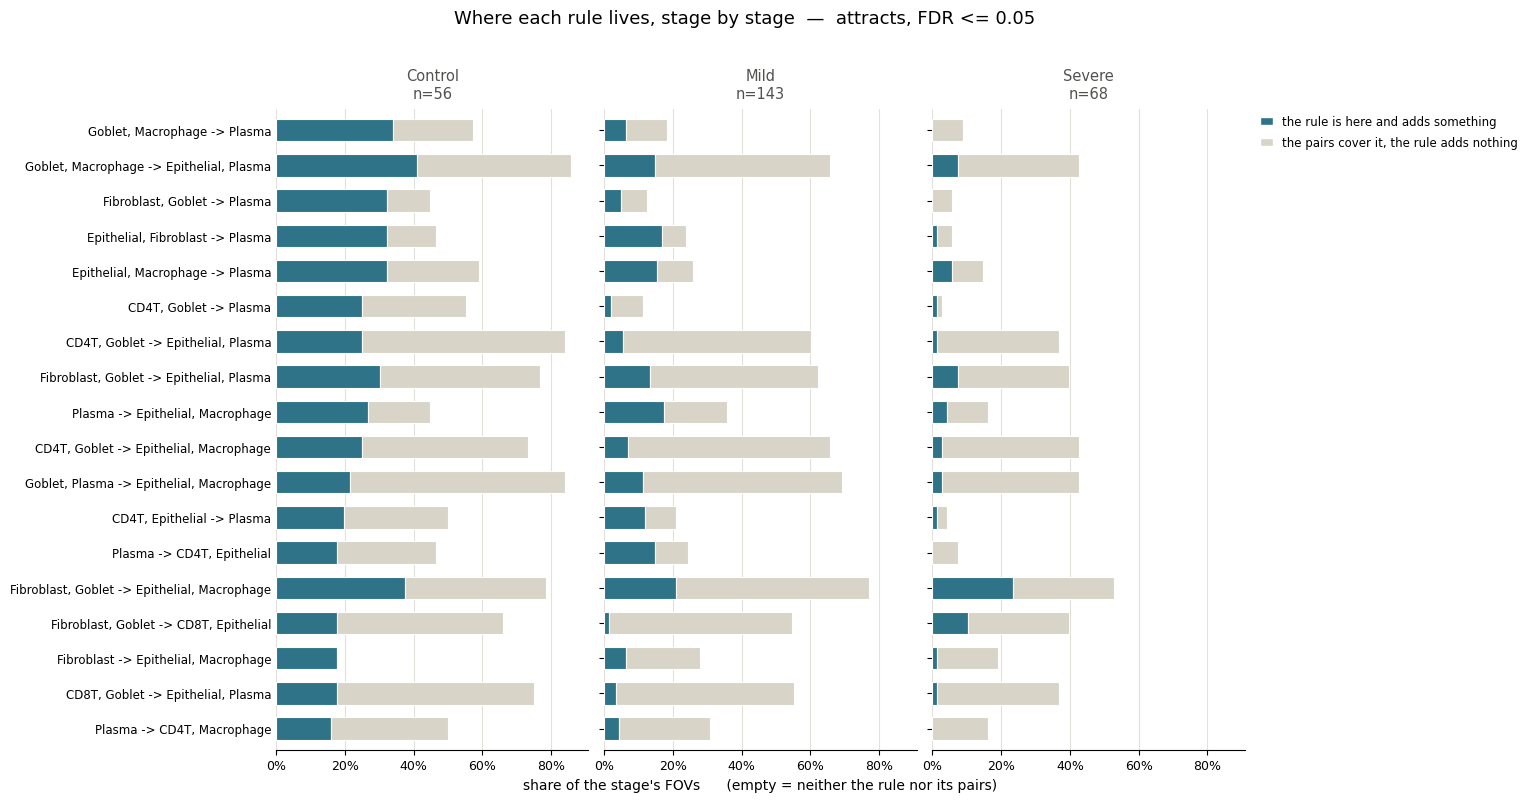

In [10]:
top = movers(counts, value='informative')
sv.plot_stage_bars(top, STAGE_ORDER, scope=f"{KIND}, FDR <= {MAX_FDR}",
                   split_adds=SPLIT_ADDS, split_covered=SPLIT_COVERED)

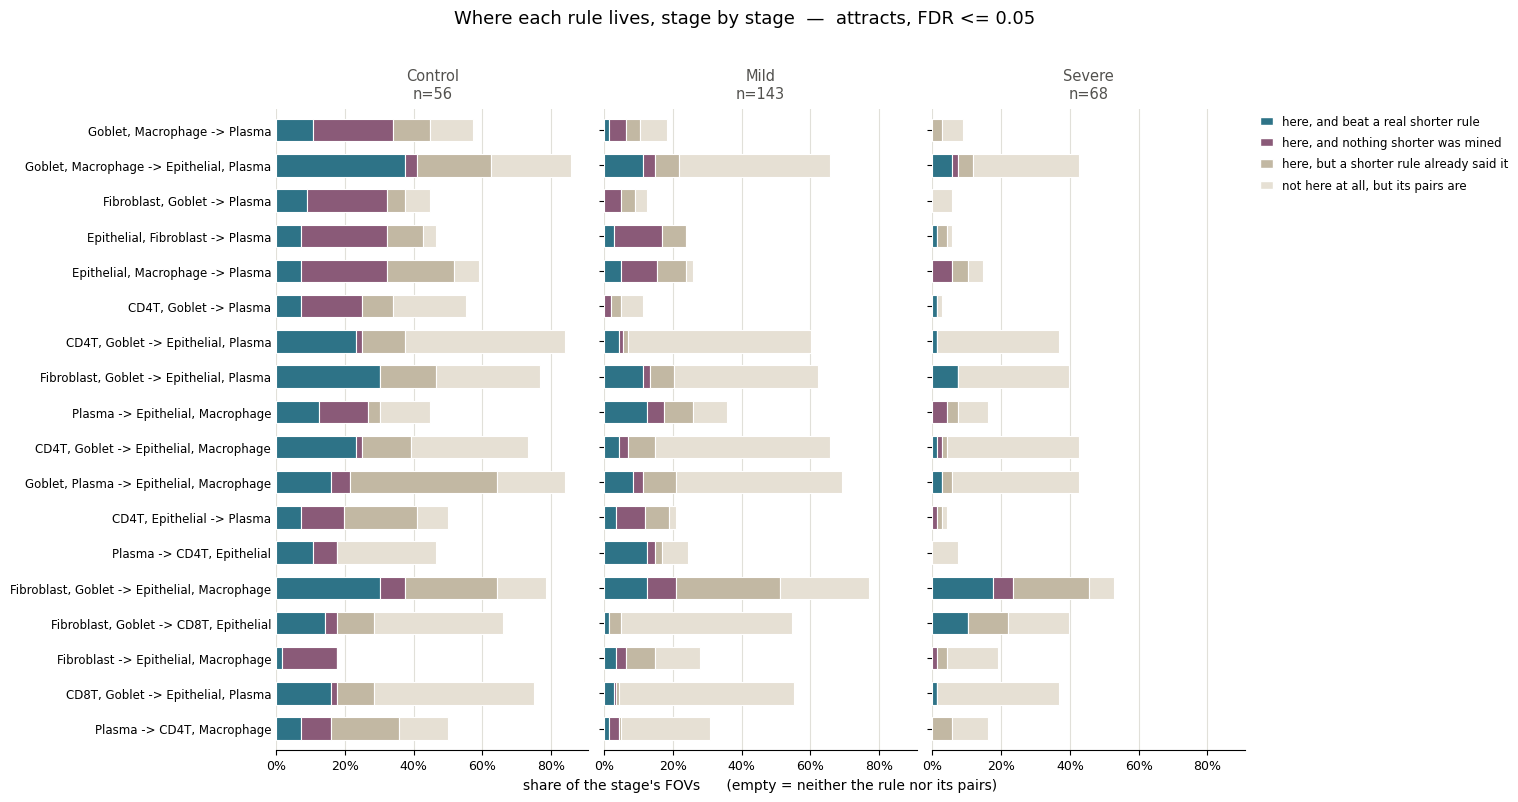

In [11]:
# The same rules, every state named.
sv.plot_stage_bars(top, STAGE_ORDER, scope=f"{KIND}, FDR <= {MAX_FDR}",
                   split_adds=True, split_covered=True)

1015 rules with 5+ FOVs behind them in every stage


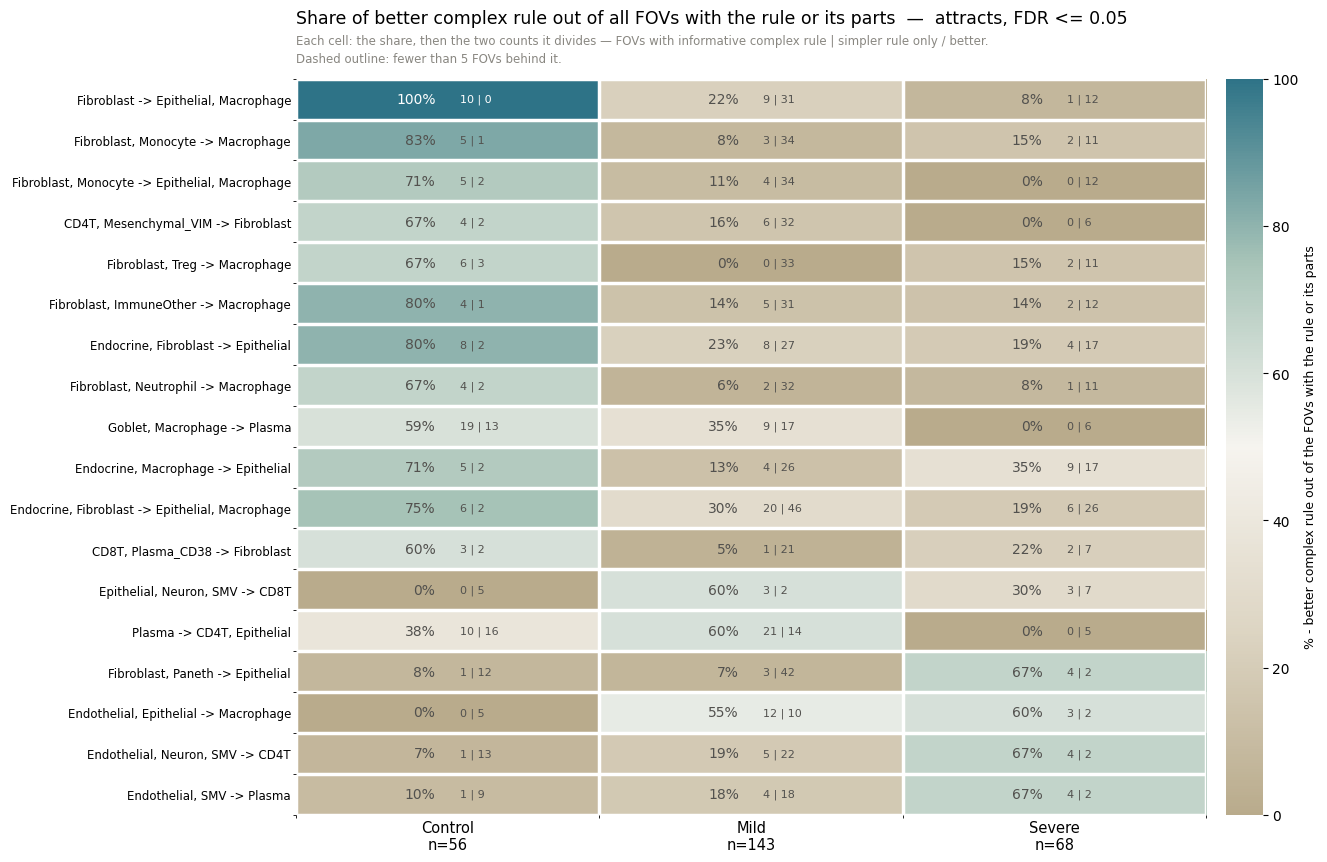

In [12]:
sv.plot_stage_heatmap(movers(counts, value='earns', min_n=MIN_N), STAGE_ORDER,
                      value='earns', min_n=MIN_N,
                      scope=f"{KIND}, FDR <= {MAX_FDR}")

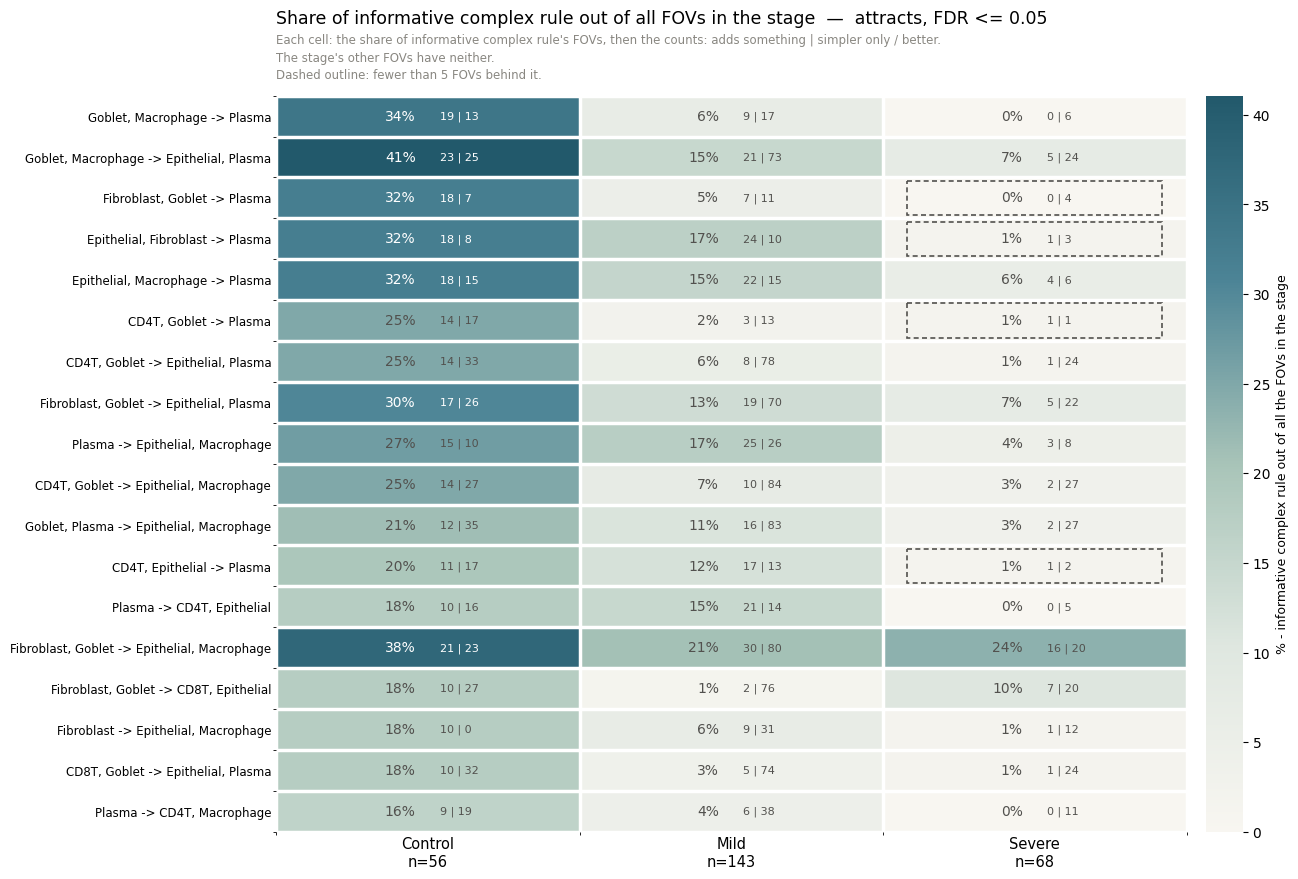

In [13]:
# The plain share instead: how much of the whole stage the rule covers.
sv.plot_stage_heatmap(top, STAGE_ORDER, value='informative', min_n=MIN_N,
                      scope=f"{KIND}, FDR <= {MAX_FDR}")

1015 rules with 5+ FOVs behind them in every stage


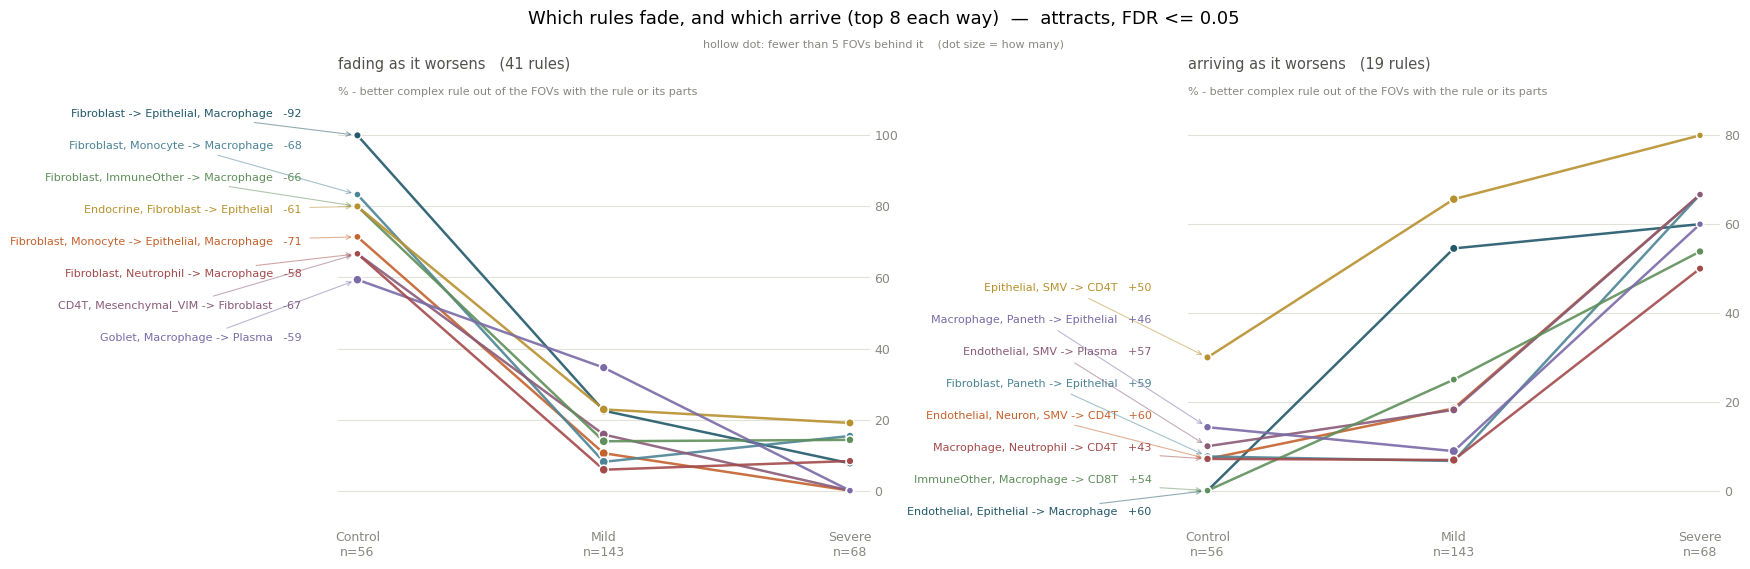

In [14]:
sv.plot_stage_trend(movers(counts, value='earns', min_n=MIN_N, top_n=60),
                    STAGE_ORDER, value='earns', min_n=MIN_N,
                    scope=f"{KIND}, FDR <= {MAX_FDR}")

### One organ at a time
`where=` filters the FOVs and the denominators together.

{'Control': 25, 'Mild': 40, 'Severe': 32}
243 rules worth reading in 5+ FOVs


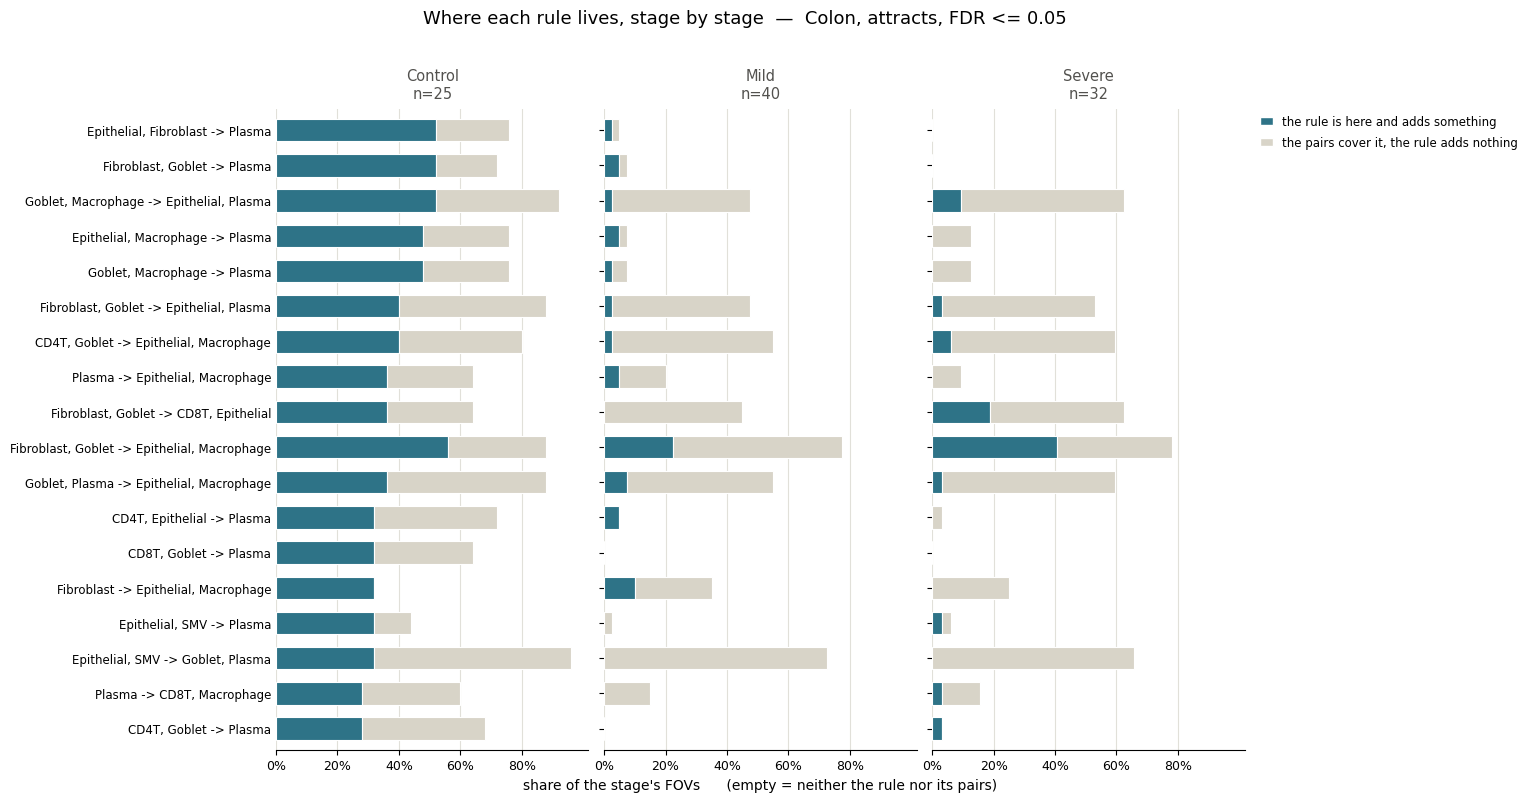

169 rules with 5+ FOVs behind them in every stage


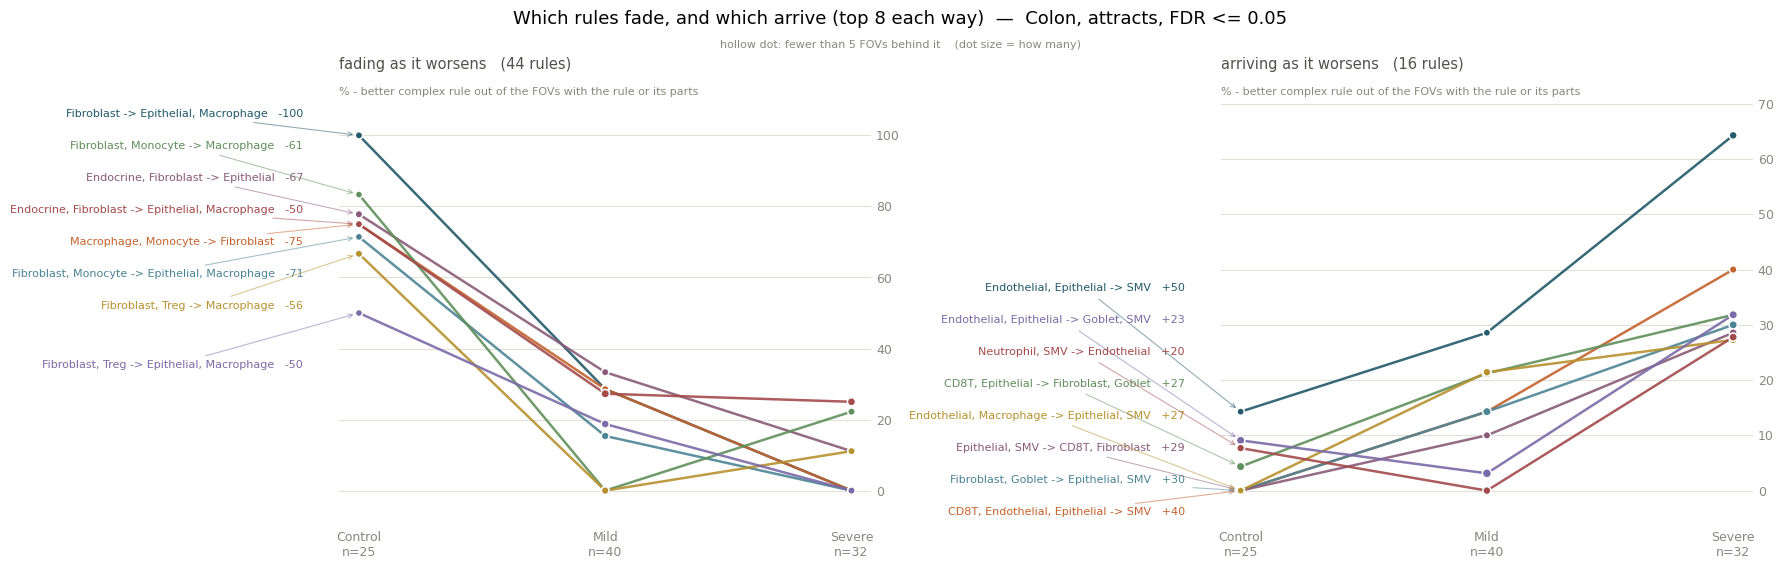

{'Control': 31, 'Mild': 103, 'Severe': 36}
988 rules worth reading in 5+ FOVs


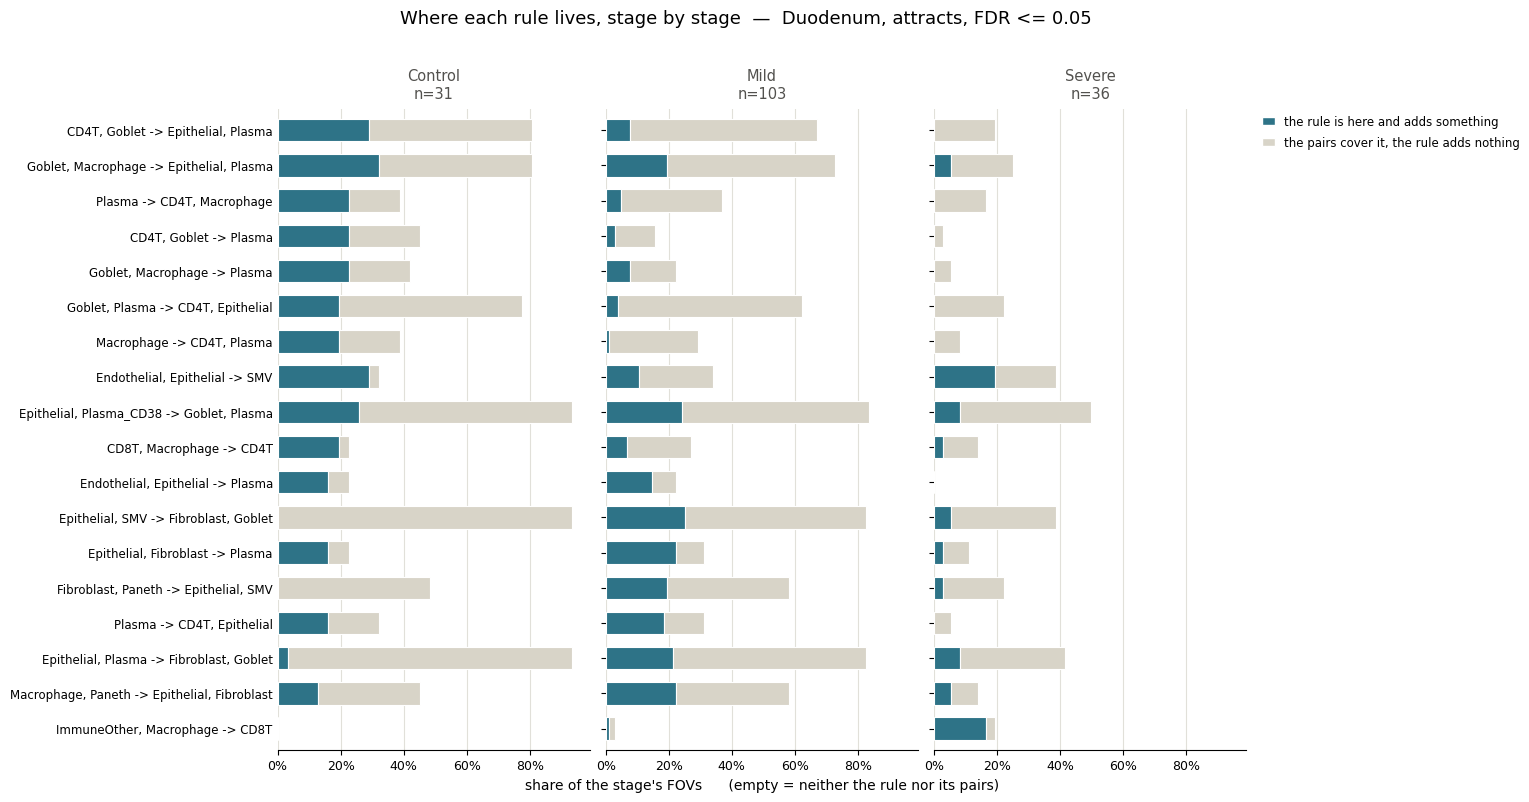

370 rules with 5+ FOVs behind them in every stage


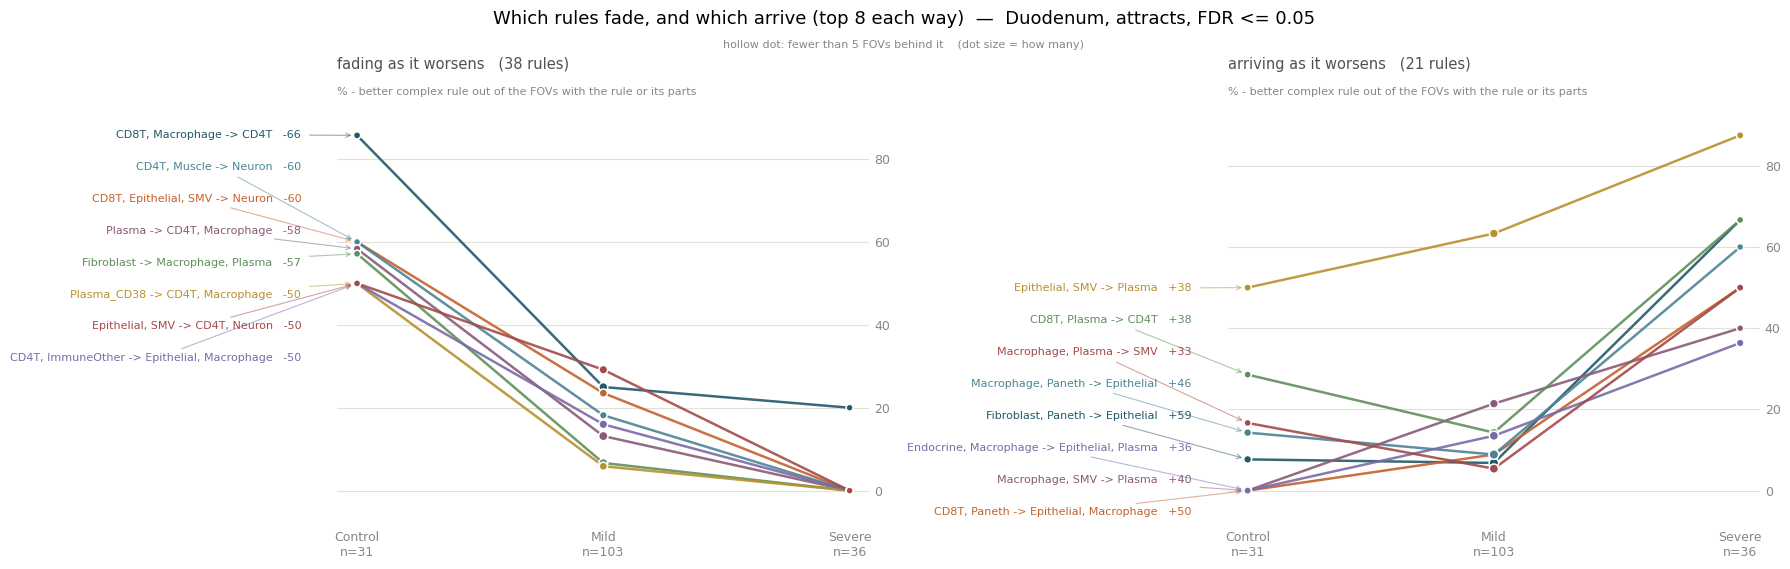

In [15]:
for organ in ORGAN_ORDER:
    organ_counts = stage_counts(ready, df_fovs, where={'Organ': organ})
    sv.plot_stage_bars(movers(organ_counts, value='informative'), STAGE_ORDER,
                       scope=f"{organ}, {KIND}, FDR <= {MAX_FDR}",
                       split_adds=SPLIT_ADDS, split_covered=SPLIT_COVERED)
    sv.plot_stage_trend(movers(organ_counts, value='earns', min_n=MIN_N, top_n=60),
                        STAGE_ORDER, value='earns', min_n=MIN_N,
                        scope=f"{organ}, {KIND}, FDR <= {MAX_FDR}")